# EDA — Prédiction du risque d'annulation
**Maeva — Mastère DIA Paris**

Analyse exploratoire du dataset `v_dataset_annulation`.
Objectif : comprendre la structure des données, la cible, et valider les signaux clés (condition Flex, canal, engagement email) avant la modélisation.

---

## 0. Installation (une seule fois)

In [2]:
# %pip install pandas numpy matplotlib seaborn google-cloud-bigquery db-dtypes pyarrow

## 1. Imports & configuration

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

# Palette cohérente
C_ANNUL = '#e74c3c'   # annulation
C_MAINT = '#2ecc71'   # maintenu
C_BLUE  = '#3498db'
C_PURP  = '#9b59b6'

# Dossier pour sauvegarder les graphiques (pour le mémoire)
os.makedirs('figures', exist_ok=True)
print('Imports OK')

Imports OK


## 2. Chargement des données
Lit le CSV local en priorité ; si absent, recharge depuis BigQuery.

In [4]:
CSV_PATH = 'data/dataset_anon.csv'   # version anonymisée (sans email)
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f'{df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Taux annulation : {df["y_annulation"].mean()*100:.2f}%')

310,862 lignes x 44 colonnes
Taux annulation : 7.27%


In [5]:
# conditions_maeva = ['Flexi', 'Flexi+', 'NoFlex', 'NoFlex (<J30)']
# df = df[df['cond_annulation'].isin(conditions_maeva)].copy()
# print(f'{len(df):,} dossiers après filtre Maeva')
# print(f'Taux annulation : {df["y_annulation"].mean()*100:.2f}%')

In [6]:
df.head(10)

,dossier_cle,date_resa,anticipation_jours,duree_sejour,canal,canal_detail,groupe_fournisseur,periode_depart,periode_vacances,mois_resa,jour_semaine_resa,dossier_nb_pax_total,dossier_nb_pax_adultes,nb_mineur,nb_bebe,type_produit,theme_station,region_destination,type_hebergement,distance_km,nb_dossiers_anterieurs,est_client_vip,device_resa,pays_client,prix_total_ttc,acompte_verse,type_paiement,nb_produits_total,nb_prestations,nb_clics_90j,nb_ouvertures_90j,nb_desabo_90j,nb_campagnes_recues,a_interagi_email,recence_email_jours,nb_campagnes_cliquees,nb_urls_distinctes_cliquees,taux_clic_sur_ouverture,segment_email,est_dans_crm,cond_annulation,est_assure_annulation,dossier_etat,y_annulation
0,12523543,2025-11-03,54,7,CE Global,CE - PV,Agences Immos,Vac Nouvel An,Autre depart,11,2,1,1,NaN,NaN,0,montagne,rhône-alpes,location de particulier,21.088,1,0,desktop,FRANCE,760.91,1,Paiement en 2 fois,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,Flexi,1,RESA,0
1,9983081,2025-01-05,202,7,CE Global,CE - PV,Produits Distribution Camping,ETE - Juillet,Autre depart,1,1,4,4,2.0,0.0,0,campagne,midi-pyrénées,camping,709.679,1,0,desktop,FRANCE,694.00,1,Paiement en 2 fois,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,Flexi,1,RESA,0
2,13545653,2026-03-15,41,7,Sites web,maeva.com,Produits Distribution Camping,Vac Printemps,Autre depart,3,1,4,4,2.0,0.0,0,mer,aquitaine,camping,513.018,1,0,tablet,FRANCE,659.00,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,Flexi,1,RESA,0
3,14076593,2026-04-27,26,2,CE Global,CE - PV CGOS,Produits Distribution Camping,Avt ÉTÉ,Autre depart,4,2,2,2,0.0,0.0,0,mer,aquitaine,camping,399.049,1,0,mobile,FRANCE,167.20,1,NaN,1,0,3,3,0,4,1,0,2,2,1.0,engage,1,NoFlex (<J30),0,RESA,0
4,9650481,2024-10-27,3,4,CE Global,CE - PV,Produits Distribution Camping,Vac Toussaint,Autre depart,10,1,4,4,2.0,0.0,0,mer,aquitaine,camping,381.464,1,0,desktop,FRANCE,475.00,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,NoFlex (<J30),0,RESA,0
5,13706043,2026-03-29,28,2,CE Global,CE - PV,Produits Distribution Camping,Vac Printemps,Autre depart,3,1,5,5,1.0,1.0,0,mer,aquitaine,camping,509.776,1,0,mobile,FRANCE,167.00,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,NoFlex (<J30),0,RESA,0
6,12889733,2026-01-11,174,14,CE Global,CE - PV CNAS,Produits Distribution Camping,ETE - Juillet,Autre depart,1,1,3,3,2.0,0.0,0,mer,aquitaine,camping,385.820,2,0,desktop,FRANCE,1876.00,1,Paiement en 3 fois,1,0,0,0,0,1,0,3,0,0,0.0,inactif,1,Flexi,1,RESA,0
7,13845933,2026-04-09,3,5,CE Global,CE - PV,Produits Distribution Camping,Vac Printemps,Autre depart,4,5,4,4,2.0,0.0,0,mer,aquitaine,camping,383.789,1,0,desktop,FRANCE,492.00,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,NoFlex (<J30),0,RESA,0
8,9054301,2024-07-18,30,7,CE Global,CE - PV,Produits Distribution Camping,ETE - Aout,Autre depart,7,5,4,4,2.0,0.0,0,mer,aquitaine,camping,340.534,1,0,desktop,FRANCE,1329.00,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,Flexi,1,RESA,0
9,10967391,2025-04-18,120,7,CE Global,CE - PV CGOS,Agences Immos,ETE - Aout,Autre depart,4,6,1,1,NaN,NaN,0,mer,languedoc-roussillon,maisons & villas,226.167,2,0,desktop,FRANCE,1569.74,1,NaN,1,0,0,0,0,0,0,999,0,0,0.0,inactif,0,Flexi,1,RESA,0


## 3. Vue d'ensemble

In [7]:
# Types + valeurs manquantes
apercu = pd.DataFrame({
    'type'    : df.dtypes.astype(str),
    'n_manquant': df.isnull().sum(),
    'pct_null'  : (df.isnull().mean() * 100).round(2),
    'n_unique'  : df.nunique()
})
print('=== APERÇU DES COLONNES ===')
apercu

=== APERÇU DES COLONNES ===


,type,n_manquant,pct_null,n_unique
dossier_cle,int64,0,0.00,310862
date_resa,object,0,0.00,730
anticipation_jours,int64,0,0.00,433
duree_sejour,int64,0,0.00,41
canal,object,0,0.00,14
canal_detail,object,0,0.00,135
groupe_fournisseur,object,0,0.00,9
periode_depart,object,0,0.00,12
periode_vacances,object,0,0.00,1
mois_resa,int64,0,0.00,12


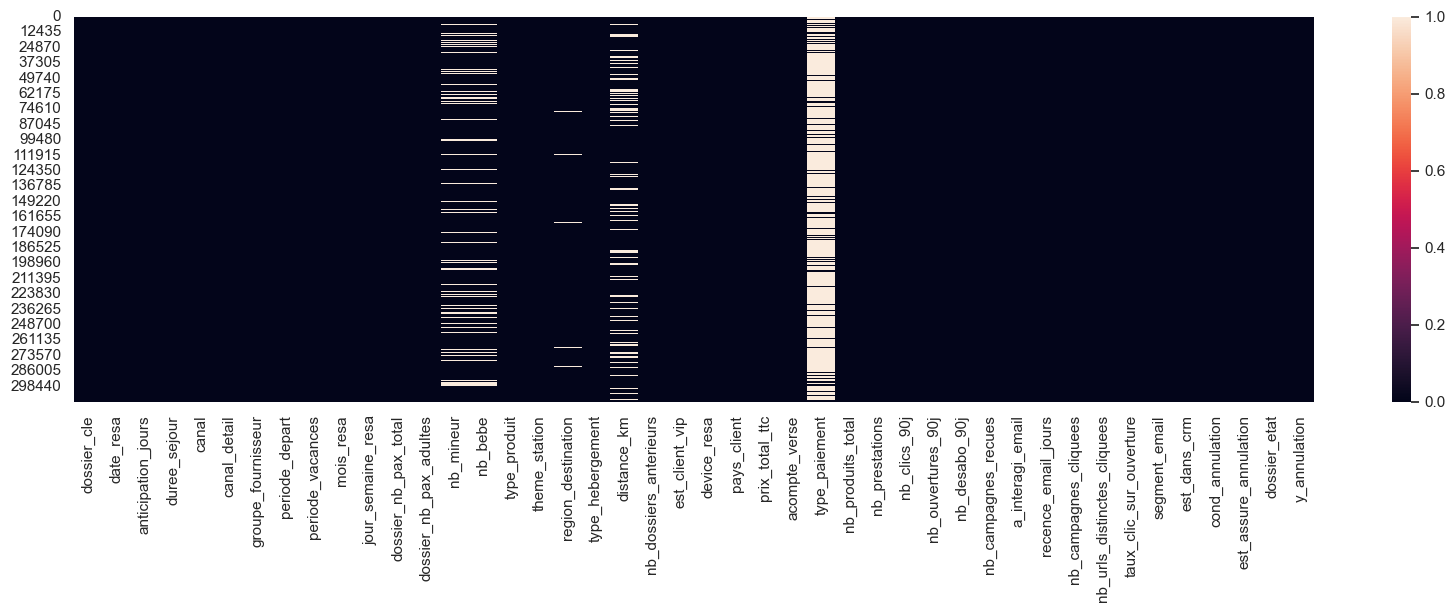

In [8]:
plt.figure(figsize=(20, 5))
sns.heatmap(df.isnull(), cbar=True)
plt.show()

In [9]:
# Colonnes avec valeurs manquantes uniquement
manq = apercu[apercu['n_manquant'] > 0].sort_values('pct_null', ascending=False)
if len(manq):
    print('Colonnes avec valeurs manquantes :')
    display(manq)
else:
    print('Aucune valeur manquante (les COALESCE de la vue SQL ont fait leur travail).')

Colonnes avec valeurs manquantes :


,type,n_manquant,pct_null,n_unique
type_paiement,object,256186,82.41,2
distance_km,float64,62391,20.07,167052
nb_mineur,float64,48400,15.57,21
nb_bebe,float64,48400,15.57,12
region_destination,object,2842,0.91,105
pays_client,object,1,0.00,121


In [10]:
df['cond_annulation'].value_counts().sort_index()

cond_annulation
Flexi            147578
Flexi+             9478
NoFlex            20058
NoFlex (<J30)    133748
Name: count, dtype: int64

In [11]:
# Statistiques descriptives des variables numériques
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
dossier_cle,310862.0,11606578.11,1608802.22,8848651.00,10286353.50,11455723.00,12907220.50,14965163.00
anticipation_jours,310862.0,58.97,58.56,-422.00,13.00,37.00,93.00,391.00
duree_sejour,310862.0,6.49,3.36,1.00,4.00,7.00,7.00,91.00
mois_resa,310862.0,5.55,3.13,1.00,3.00,5.00,8.00,12.00
jour_semaine_resa,310862.0,3.87,1.95,1.00,2.00,4.00,6.00,7.00
dossier_nb_pax_total,310862.0,3.12,1.87,1.00,2.00,3.00,4.00,121.00
dossier_nb_pax_adultes,310862.0,3.12,1.87,1.00,2.00,3.00,4.00,121.00
nb_mineur,262462.0,1.03,1.20,0.00,0.00,1.00,2.00,25.00
nb_bebe,262462.0,0.06,0.28,0.00,0.00,0.00,0.00,14.00
type_produit,310862.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 4. Traitement des valeurs manquantes

In [29]:

# ── nb_mineur et nb_bebe ─────────────────────────────────────
# Ces deux champs sont vides quand le dossier ne contient
# ni mineur ni bébé — un null signifie 0, pas une donnée absente.
# Je remplace donc par 0 en toute légitimité.
for col in ['nb_mineur', 'nb_bebe']:
    if col in df.columns:
        n = df[col].isnull().sum()
        df[col] = df[col].fillna(0)
        print(f"✔ {col} : {n:,} nulls → remplacés par 0")
        print(f"  (logique : pas de {col.split('_')[1]} dans le dossier = 0)\n")

# ── distance_km ──────────────────────────────────────────────
# 20% de valeurs manquantes — probablement des destinations
# pour lesquelles la distance domicile/station n'a pas pu
# être calculée. J'impute par la médiane, qui est robuste
# aux distances extrêmes.
if 'distance_km' in df.columns:
    n      = df['distance_km'].isnull().sum()
    mediane = df['distance_km'].median()
    df['distance_km'] = df['distance_km'].fillna(mediane)
    print(f"✔ distance_km : {n:,} nulls → imputés par la médiane ({mediane:.0f} km)")
    print(f"  Choix de la médiane : robuste aux distances extrêmes,")
    print(f"  et le taux d'annulation est quasi identique entre dossiers")
    print(f"  avec/sans distance connue (7.29% vs 7.19%) — pas de biais.\n")

# ── region_destination ───────────────────────────────────────
# Seulement 0.91% de nulls — je remplace par 'inconnu'
# pour ne pas perdre ces quelques lignes au moment
# de l'encodage catégoriel dans le pipeline.
if 'region_destination' in df.columns:
    n = df['region_destination'].isnull().sum()
    df['region_destination'] = df['region_destination'].fillna('inconnu')
    print(f"✔ region_destination : {n:,} nulls → remplacés par 'inconnu'")
    print(f"  (taux de null négligeable : < 1%)\n")

# ── pays_client ──────────────────────────────────────────────
# 1 seul null — aucun impact, je remplace par 'inconnu'
if 'pays_client' in df.columns:
    n = df['pays_client'].isnull().sum()
    df['pays_client'] = df['pays_client'].fillna('inconnu')
    print(f"✔ pays_client : {n} null → remplacé par 'inconnu'\n")

# ── type_paiement ────────────────────────────────────────────
# 82% de nulls — cette variable est beaucoup trop lacunaire
# pour apporter une information fiable au modèle.
# Je la supprime directement.
if 'type_paiement' in df.columns:
    df = df.drop(columns=['type_paiement'])
    print("✔ type_paiement supprimé (82% de nulls — trop lacunaire)\n")



✔ nb_mineur : 0 nulls → remplacés par 0
  (logique : pas de mineur dans le dossier = 0)

✔ nb_bebe : 0 nulls → remplacés par 0
  (logique : pas de bebe dans le dossier = 0)

✔ distance_km : 62,391 nulls → imputés par la médiane (520 km)
  Choix de la médiane : robuste aux distances extrêmes,
  et le taux d'annulation est quasi identique entre dossiers
  avec/sans distance connue (7.29% vs 7.19%) — pas de biais.

✔ region_destination : 2,842 nulls → remplacés par 'inconnu'
  (taux de null négligeable : < 1%)

✔ pays_client : 1 null → remplacé par 'inconnu'



In [30]:
# ── Vérification finale ──────────────────────────────────────
print("=== VÉRIFICATION : PLUS AUCUN NULL CRITIQUE ===")
nulls_restants = df.isnull().sum()
nulls_restants = nulls_restants[nulls_restants > 0]

if len(nulls_restants) == 0:
    print("✅ Aucune valeur manquante — dataset prêt pour la modélisation.")
else:
    print("Nulls résiduels (non bloquants) :")
    print((nulls_restants / len(df) * 100).round(2).to_frame('pct_null'))

=== VÉRIFICATION : PLUS AUCUN NULL CRITIQUE ===
✅ Aucune valeur manquante — dataset prêt pour la modélisation.


## 5. Variable cible : `y_annulation`

=== DISTRIBUTION DE LA CIBLE ===
  Y=0 (maintenu)  : 288,254 (92.73%)
  Y=1 (annulé)    : 22,608 (7.27%)

  Ratio de déséquilibre : 1 annulation pour 12.8 maintiens


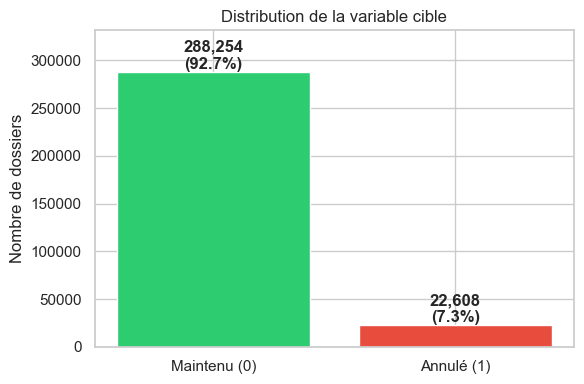

In [13]:
counts = df['y_annulation'].value_counts().sort_index()
pct    = df['y_annulation'].value_counts(normalize=True).sort_index() * 100

print('=== DISTRIBUTION DE LA CIBLE ===')
print(f"  Y=0 (maintenu)  : {counts[0]:,} ({pct[0]:.2f}%)")
print(f"  Y=1 (annulé)    : {counts[1]:,} ({pct[1]:.2f}%)")
print(f"\n  Ratio de déséquilibre : 1 annulation pour {counts[0]/counts[1]:.1f} maintiens")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Maintenu (0)', 'Annulé (1)'], counts.values, color=[C_MAINT, C_ANNUL])
ax.set_title('Distribution de la variable cible')
ax.set_ylabel('Nombre de dossiers')
for b, v, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.margins(y=0.15)
plt.tight_layout(); plt.savefig('figures/01_cible.png', dpi=150); plt.show()

## 5. La condition d'annulation (Flex) — variable structurelle clé
On attend un gradient : plus la couverture est forte, plus on annule.

=== TAUX D'ANNULATION PAR CONDITION FLEX ===
                     nb  taux_annul
cond_annulation                    
Flexi+             9478       17.66
Flexi            147578        9.60
NoFlex            20058        4.51
NoFlex (<J30)    133748        4.39


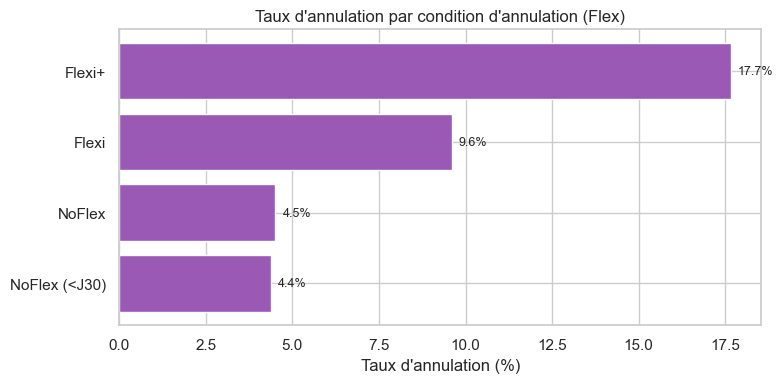

In [14]:
def taux_par(col, min_n=30, top=None):
    """Taux d'annulation + volume par modalité d'une variable catégorielle."""
    g = (df.groupby(col)['y_annulation']
           .agg(nb='count', taux_annul='mean')
           .assign(taux_annul=lambda x: (x['taux_annul']*100).round(2))
           .query('nb >= @min_n')
           .sort_values('taux_annul', ascending=False))
    return g.head(top) if top else g

cond = taux_par('cond_annulation')
print('=== TAUX D\'ANNULATION PAR CONDITION FLEX ===')
print(cond)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cond.index, cond['taux_annul'], color=C_PURP)
ax.invert_yaxis()
ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par condition d\'annulation (Flex)')
for b, v in zip(bars, cond['taux_annul']):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('figures/02_cond_annulation.png', dpi=150); plt.show()

In [15]:
# Synthèse couvert vs non couvert
if 'est_assure_annulation' in df.columns:
    g = (df.groupby('est_assure_annulation')['y_annulation']
           .agg(nb='count', taux='mean'))
    g['taux'] = (g['taux']*100).round(2)
    g.index = ['Non couvert (0)', 'Couvert (1)']
    print('=== COUVERT vs NON COUVERT ===')
    print(g)

=== COUVERT vs NON COUVERT ===
                     nb   taux
Non couvert (0)  153806   4.40
Couvert (1)      157056  10.08


## 6. Le canal de vente

                           nb  taux_annul
canal                                    
Autres                    537       20.86
Site web Parcel          1194       15.75
Ventes sur place         2826       11.85
Booking                 13522       10.96
Sites web Vacansoleil   20637        9.42
Site Web affiliés         137        8.76
Partenaires             48516        8.13
Sites web              101136        7.94
Marques blanches         2273        7.79
Ventes Flash            11184        7.09
Sites web 5C             2486        6.72
CE Global               81585        5.21


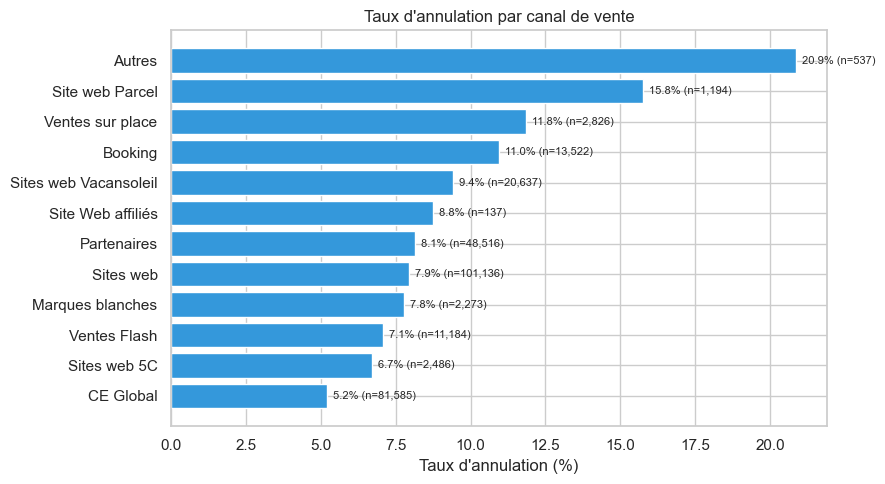

In [16]:
canal = taux_par('canal', top=12)
print(canal)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(canal.index, canal['taux_annul'], color=C_BLUE)
ax.invert_yaxis()
ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par canal de vente')
for b, v, n in zip(bars, canal['taux_annul'], canal['nb']):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}% (n={n:,})', va='center', fontsize=8)
plt.tight_layout(); plt.savefig('figures/03_canal.png', dpi=150); plt.show()

## 7. Saisonnalité & destination

=== PAR THÈME DE STATION ===
                   nb  taux_annul
theme_station                    
montagne        68992        8.46
mer            199591        7.03
ville            3657        6.67
campagne        37705        6.49
paris             917        4.91


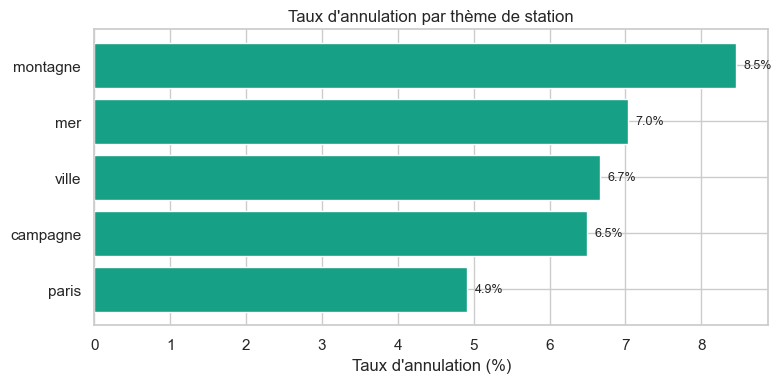

In [17]:
# Thème de station
if 'theme_station' in df.columns:
    theme = taux_par('theme_station', top=10)
    print('=== PAR THÈME DE STATION ===')
    print(theme)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(theme.index, theme['taux_annul'], color='#16a085')
    ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
    ax.set_title('Taux d\'annulation par thème de station')
    for b, v in zip(bars, theme['taux_annul']):
        ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.savefig('figures/04_theme.png', dpi=150); plt.show()

In [18]:
# Période de départ
if 'periode_depart' in df.columns:
    per = taux_par('periode_depart', top=15)
    print('=== PAR PÉRIODE DE DÉPART ===')
    print(per)

=== PAR PÉRIODE DE DÉPART ===
                   nb  taux_annul
periode_depart                   
Vac Nouvel An    5560       11.12
Avt Noel         3800        9.92
Vac Noel         4090        9.22
Avt Printemps   12790        8.32
Vac Toussaint    5477        8.18
Vac Hiver       20769        8.14
Avt Hiver       17192        7.96
Avt ÉTÉ         88120        7.66
Avt Toussaint   27368        6.96
ETE - Juillet   42449        6.49
ETE - Aout      47803        6.32
Vac Printemps   35444        6.30


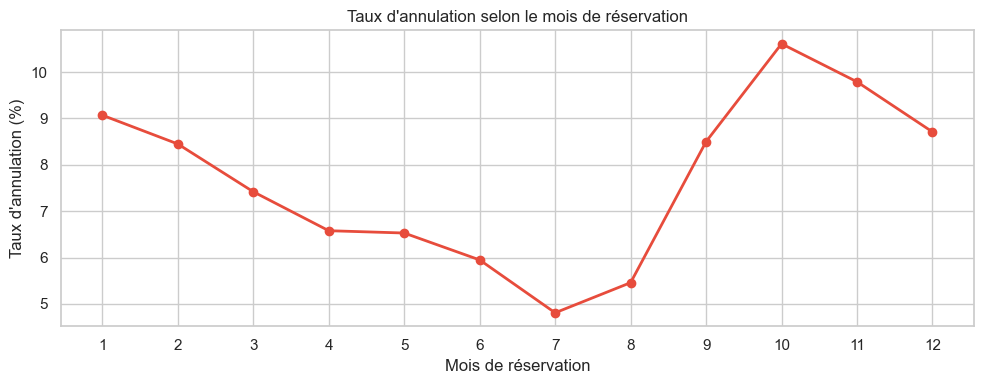

In [19]:
# Mois de réservation (saisonnalité de la prise de décision)
mois = (df.groupby('mois_resa')['y_annulation']
          .agg(nb='count', taux='mean').assign(taux=lambda x:(x['taux']*100).round(2)))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mois.index, mois['taux'], marker='o', color=C_ANNUL, lw=2)
ax.set_xticks(range(1,13))
ax.set_xlabel('Mois de réservation'); ax.set_ylabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation selon le mois de réservation')
plt.tight_layout(); plt.savefig('figures/05_mois.png', dpi=150); plt.show()

## 8. Variables numériques de contexte

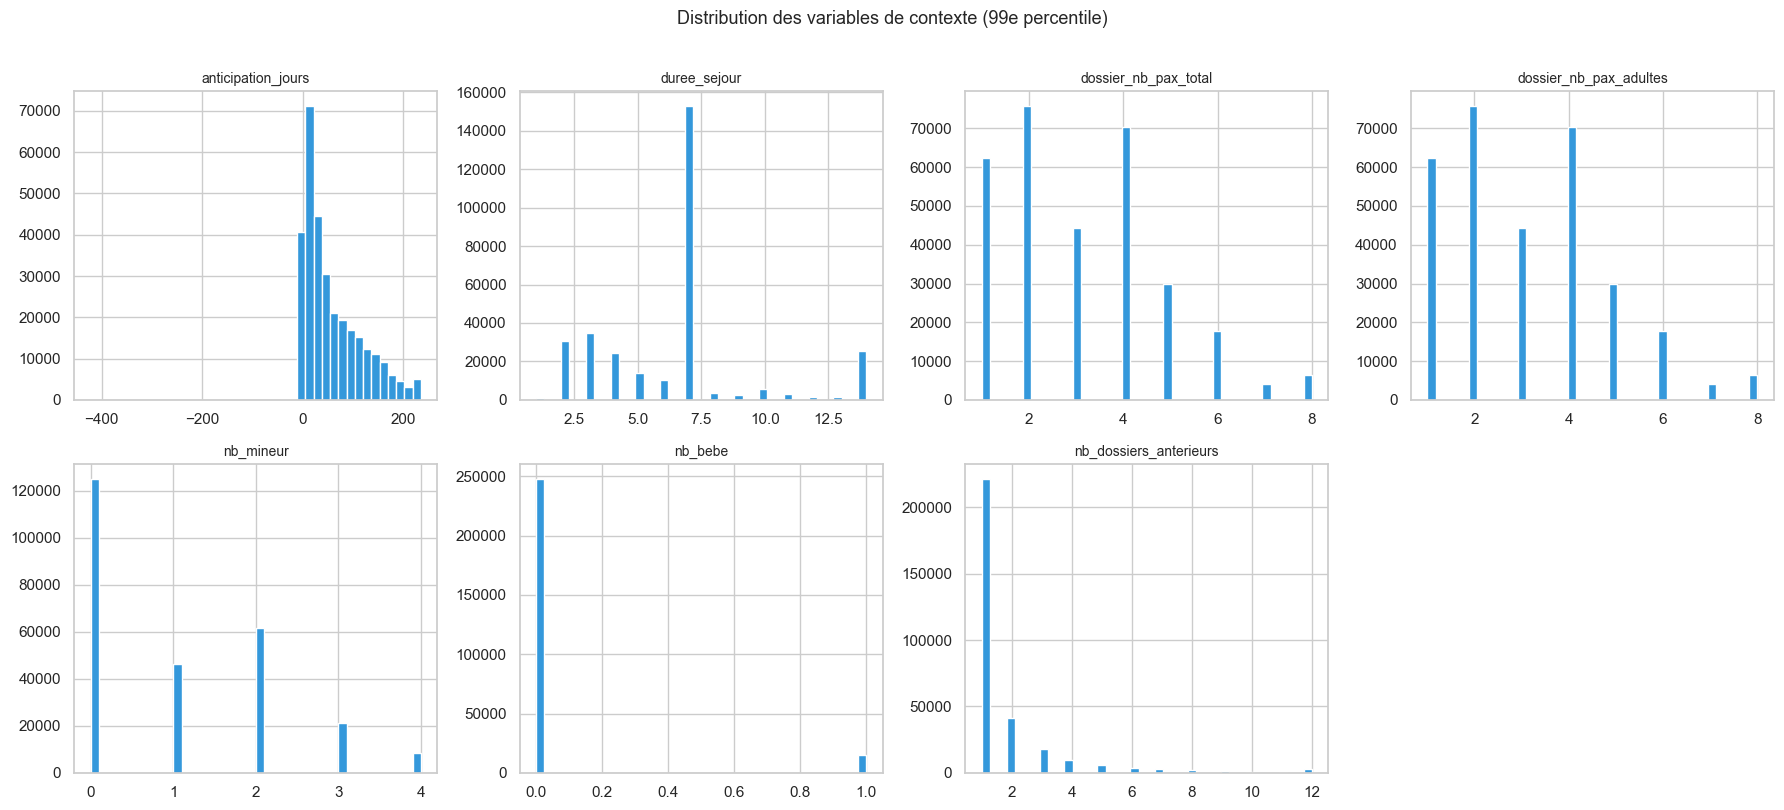

In [20]:
num_context = ['anticipation_jours', 'duree_sejour', 'dossier_nb_pax_total',
               'dossier_nb_pax_adultes', 'nb_mineur', 'nb_bebe',
               'nb_dossiers_anterieurs']
num_context = [c for c in num_context if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.flatten()
for i, col in enumerate(num_context):
    data = df[col].clip(upper=df[col].quantile(0.99))  # coupe les outliers extrêmes pour l'affichage
    axes[i].hist(data, bins=40, color=C_BLUE, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
for j in range(len(num_context), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution des variables de contexte (99e percentile)', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig('figures/06_num_context.png', dpi=150); plt.show()

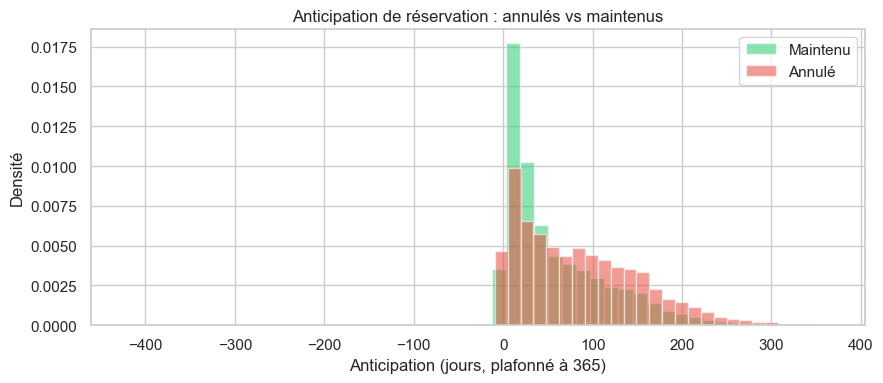

In [21]:
# Anticipation : annulés vs maintenus (un signal souvent fort)
fig, ax = plt.subplots(figsize=(9, 4))
for y, c, lab in [(0, C_MAINT, 'Maintenu'), (1, C_ANNUL, 'Annulé')]:
    d = df.loc[df['y_annulation']==y, 'anticipation_jours'].clip(upper=365)
    ax.hist(d, bins=50, alpha=0.55, color=c, label=lab, density=True)
ax.set_xlabel('Anticipation (jours, plafonné à 365)'); ax.set_ylabel('Densité')
ax.set_title('Anticipation de réservation : annulés vs maintenus')
ax.legend()
plt.tight_layout(); plt.savefig('figures/07_anticipation.png', dpi=150); plt.show()

## 9. Couverture email (CRM) — la contrainte Batch
Rappel : Batch ne couvre que ~7 mois, donc une minorité de dossiers a un historique email.

In [22]:
if 'est_dans_crm' in df.columns:
    n_crm = int(df['est_dans_crm'].sum())
    pct_crm = df['est_dans_crm'].mean()*100
    print(f"Dossiers AVEC historique email : {n_crm:,} ({pct_crm:.1f}%)")
    print(f"Dossiers SANS historique email : {len(df)-n_crm:,} ({100-pct_crm:.1f}%)")

# Distribution du segment d'engagement
seg = df['segment_email'].value_counts()
print('\n=== RÉPARTITION DES SEGMENTS EMAIL ===')
print(seg)

Dossiers AVEC historique email : 38,092 (12.3%)
Dossiers SANS historique email : 272,770 (87.7%)

=== RÉPARTITION DES SEGMENTS EMAIL ===
segment_email
inactif              287993
ouvreur_seulement     12639
peu_engage             3776
engage                 3024
tres_engage            2935
desabonne               495
Name: count, dtype: int64


                       nb  taux_annul
segment_email                        
tres_engage          2935        7.84
inactif            287993        7.33
peu_engage           3776        7.31
engage               3024        6.65
ouvreur_seulement   12639        6.03
desabonne             495        5.45


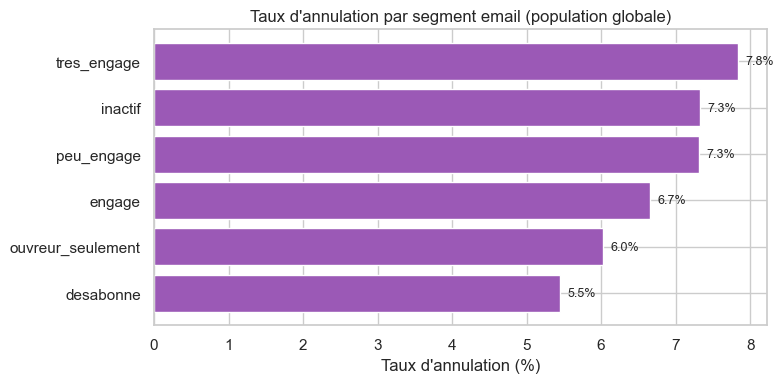

In [23]:
# Taux d'annulation par segment email (toute la population)
seg_taux = taux_par('segment_email')
print(seg_taux)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(seg_taux.index, seg_taux['taux_annul'], color=C_PURP)
ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par segment email (population globale)')
for b, v in zip(bars, seg_taux['taux_annul']):
    ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('figures/08_segment_global.png', dpi=150); plt.show()

## 10. ★ ANALYSE CENTRALE : l'email chez les clients NON couverts
C'est le cœur du mémoire : chez ceux qui perdent leur argent en annulant (non assurés), l'engagement email discrimine-t-il l'annulation ?

Population non couverte : 153,806 dossiers (taux annul. global 4.40%)

=== TAUX D'ANNULATION PAR SEGMENT EMAIL (NON COUVERTS) ===
                       nb  taux
segment_email                  
inactif            142129  4.50
peu_engage           1912  3.92
tres_engage          1395  3.51
ouvreur_seulement    6551  3.13
engage               1548  2.71
desabonne             271  1.85


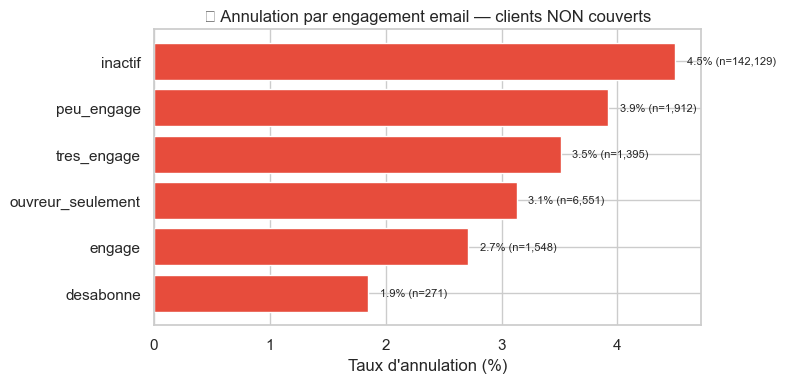

In [24]:
if 'est_assure_annulation' in df.columns:
    non_couverts = df[df['est_assure_annulation'] == 0]
    print(f'Population non couverte : {len(non_couverts):,} dossiers '
          f'(taux annul. global {non_couverts["y_annulation"].mean()*100:.2f}%)\n')

    g = (non_couverts.groupby('segment_email')['y_annulation']
                     .agg(nb='count', taux='mean')
                     .assign(taux=lambda x:(x['taux']*100).round(2))
                     .sort_values('taux', ascending=False))
    print('=== TAUX D\'ANNULATION PAR SEGMENT EMAIL (NON COUVERTS) ===')
    print(g)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(g.index, g['taux'], color=C_ANNUL)
    ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
    ax.set_title('★ Annulation par engagement email — clients NON couverts')
    for b, v, n in zip(bars, g['taux'], g['nb']):
        ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}% (n={n:,})', va='center', fontsize=8)
    plt.tight_layout(); plt.savefig('figures/09_email_non_couverts.png', dpi=150); plt.show()

## 11. Matrice de corrélation (variables numériques)

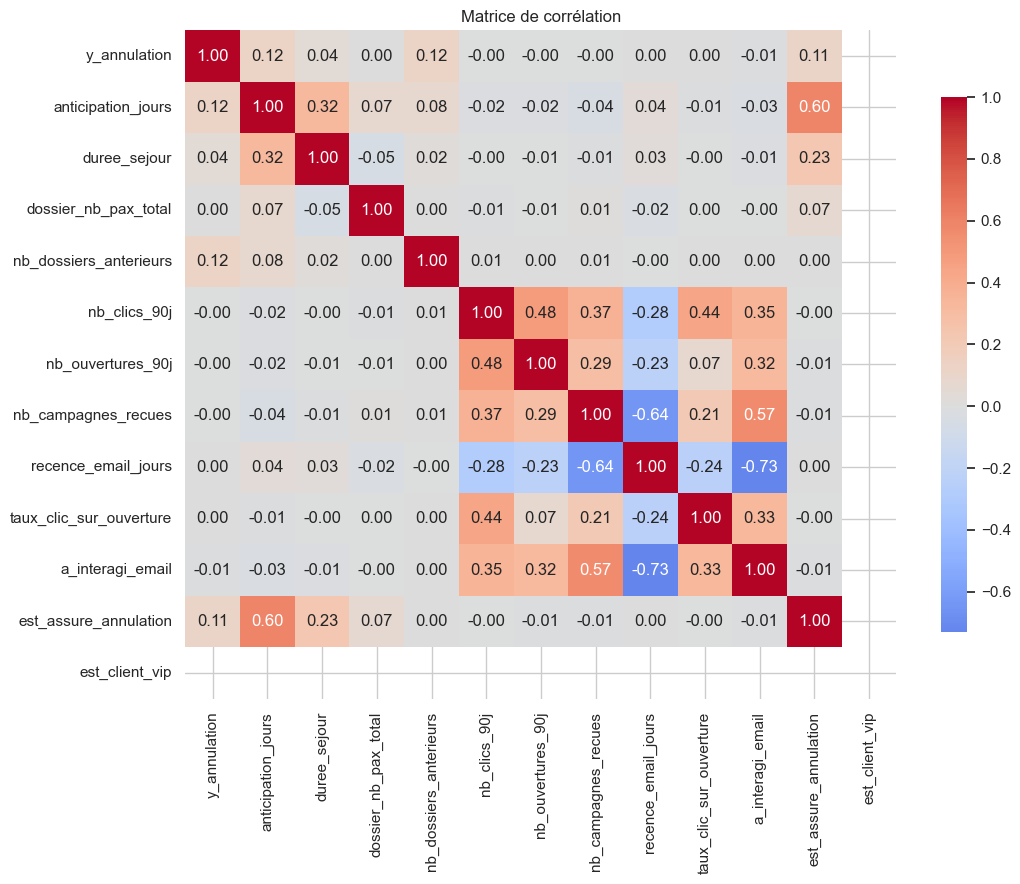

In [25]:
corr_cols = ['y_annulation', 'anticipation_jours', 'duree_sejour',
             'dossier_nb_pax_total', 'nb_dossiers_anterieurs',
             'nb_clics_90j', 'nb_ouvertures_90j', 'nb_campagnes_recues',
             'recence_email_jours', 'taux_clic_sur_ouverture', 'a_interagi_email',
             'est_assure_annulation', 'est_client_vip', 'a_promo']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=False, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout(); plt.savefig('figures/10_correlation.png', dpi=150); plt.show()

In [26]:
# Corrélations avec la cible, triées
corr_cible = df[corr_cols].corr()['y_annulation'].drop('y_annulation').sort_values(key=abs, ascending=False)
print('=== CORRÉLATION (Pearson) AVEC LA CIBLE ===')
print(corr_cible.round(3))

=== CORRÉLATION (Pearson) AVEC LA CIBLE ===
anticipation_jours         0.120
nb_dossiers_anterieurs     0.117
est_assure_annulation      0.109
duree_sejour               0.043
a_interagi_email          -0.008
nb_ouvertures_90j         -0.005
nb_campagnes_recues       -0.002
taux_clic_sur_ouverture    0.001
recence_email_jours        0.001
dossier_nb_pax_total       0.001
nb_clics_90j              -0.001
est_client_vip               NaN
Name: y_annulation, dtype: float64


## 12. Synthèse EDA

In [27]:
print('='*55)
print('  SYNTHÈSE EDA — DATASET ANNULATION')
print('='*55)
print(f'  Dossiers          : {len(df):,}')
print(f'  Variables         : {df.shape[1]}')
print(f'  Taux annulation   : {df["y_annulation"].mean()*100:.2f}%')
if 'est_dans_crm' in df.columns:
    print(f'  Couverture email  : {df["est_dans_crm"].mean()*100:.1f}%')
print()
print('  À retenir pour la modélisation :')
print('   - Déséquilibre modéré -> class_weight / SMOTE')
print('   - cond_annulation & canal = signaux structurels forts')
print('   - Email : signal réel mais sur une minorité (sous-ensemble CRM)')
print('   - Stratégie 2 temps : modèle global + focus est_dans_crm=1')
print('  Graphiques sauvegardés dans ./figures/')
print('='*55)

  SYNTHÈSE EDA — DATASET ANNULATION
  Dossiers          : 310,862
  Variables         : 44
  Taux annulation   : 7.27%
  Couverture email  : 12.3%

  À retenir pour la modélisation :
   - Déséquilibre modéré -> class_weight / SMOTE
   - cond_annulation & canal = signaux structurels forts
   - Email : signal réel mais sur une minorité (sous-ensemble CRM)
   - Stratégie 2 temps : modèle global + focus est_dans_crm=1
  Graphiques sauvegardés dans ./figures/


In [31]:
# ─────────────────────────────────────────────────────────────
# SAUVEGARDE DU DATASET PROPRE
# Ce fichier sera lu directement par modele_v2.ipynb.
# Je le nomme _clean pour le distinguer de la version brute.
# ─────────────────────────────────────────────────────────────
OUTPUT_PATH = 'data/dataset_annulation_clean.csv'
df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print(f"\n Dataset propre sauvegardé : {OUTPUT_PATH}")
print(f"   {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"   Taux d'annulation : {df['y_annulation'].mean()*100:.2f}%")
print(f"\n→ Ce fichier est prêt à être chargé dans modele_v2.ipynb")


 Dataset propre sauvegardé : data/dataset_annulation_clean.csv
   310,862 lignes × 45 colonnes
   Taux d'annulation : 7.27%

→ Ce fichier est prêt à être chargé dans modele_v2.ipynb
